# 06 · Feature Engineering — Advanced Interview Prep

> Feature engineering questions separate mid-level from senior DS.

## Topics
1. Encoding — OHE vs Label vs Target vs Frequency
2. Scaling — which algorithm needs which scaler
3. Missing data — MCAR / MAR / MNAR
4. Outlier treatment
5. Polynomial features
6. Cyclical date/time encoding
7. Feature importance methods — why they disagree
8. Leakage-free Pipeline
9. VIF and multicollinearity
10. Interview traps

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import (StandardScaler, MinMaxScaler, RobustScaler,
                                    OneHotEncoder, OrdinalEncoder, LabelEncoder)
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, KFold
from sklearn.feature_selection import mutual_info_classif
from sklearn.datasets import make_classification
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print('Ready')

Ready


## 1. Encoding Strategies

| Method | Use When | Pitfall |
|---|---|---|
| **Label Encoding** | Ordinal (ordered) | Implies order on nominal data |
| **One-Hot Encoding** | Nominal, cardinality < 15 | Dimensionality explosion |
| **Target Encoding** | High cardinality | Data leakage if done before split |
| **Frequency Encoding** | High cardinality, tree models | Loses class signal |

In [2]:
np.random.seed(42)
n = 500
df = pd.DataFrame({
    'City'      : np.random.choice(['Mumbai','Delhi','Bangalore','Chennai','Pune'], n),
    'Education' : np.random.choice(['HS','Bachelor','Master','PhD'], n),
    'Dept'      : np.random.choice([f'Dept_{i}' for i in range(50)], n),
    'Target'    : np.random.choice([0,1], n, p=[0.7,0.3])
})

# One-Hot
ohe = OneHotEncoder(sparse_output=False, drop='first')
city_ohe = ohe.fit_transform(df[['City']])
print('OHE City shape:', city_ohe.shape)
print('Columns:', ohe.get_feature_names_out())

# Ordinal
ord_enc = OrdinalEncoder(categories=[['HS','Bachelor','Master','PhD']])
df['Education_enc'] = ord_enc.fit_transform(df[['Education']])
print(df[['Education','Education_enc']].drop_duplicates().sort_values('Education_enc'))

# Frequency
freq_map = df['Dept'].value_counts(normalize=True).to_dict()
df['Dept_freq'] = df['Dept'].map(freq_map)
print('Freq encoding sample:', df[['Dept','Dept_freq']].head(3))

OHE City shape: (500, 4)
Columns: ['City_Chennai' 'City_Delhi' 'City_Mumbai' 'City_Pune']
  Education  Education_enc
3        HS            0.0
0  Bachelor            1.0
6    Master            2.0
1       PhD            3.0
Freq encoding sample:       Dept  Dept_freq
0  Dept_33      0.022
1  Dept_46      0.030
2   Dept_7      0.024


In [3]:
# TARGET ENCODING -- the leakage trap
# WRONG: compute on full dataset
df['Target_enc_LEAKY'] = df.groupby('City')['Target'].transform('mean')
print('LEAKY target encoding (uses test labels!):')
print(df.groupby('City')['Target_enc_LEAKY'].first().round(3))

# CORRECT: compute within each CV fold
df['Target_enc_CORRECT'] = 0.0
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for train_idx, val_idx in kf.split(df):
    city_mean = df.iloc[train_idx].groupby('City')['Target'].mean()
    df.iloc[val_idx, df.columns.get_loc('Target_enc_CORRECT')] = \
        df.iloc[val_idx]['City'].map(city_mean).fillna(df['Target'].mean())

print('Correct CV-safe target encoding:')
print(df.groupby('City')['Target_enc_CORRECT'].first().round(3))
print()
print('INTERVIEW Q: Why is target encoding before split a problem?')
print('ANSWER: Test rows target values leak into the encoding.')
print('        Model effectively sees test labels during training -> inflated CV score.')

LEAKY target encoding (uses test labels!):
City
Bangalore    0.385
Chennai      0.321
Delhi        0.274
Mumbai       0.330
Pune         0.312
Name: Target_enc_LEAKY, dtype: float64
Correct CV-safe target encoding:
City
Bangalore    0.423
Chennai      0.311
Delhi        0.270
Mumbai       0.284
Pune         0.329
Name: Target_enc_CORRECT, dtype: float64

INTERVIEW Q: Why is target encoding before split a problem?
ANSWER: Test rows target values leak into the encoding.
        Model effectively sees test labels during training -> inflated CV score.


## 2. Scaling — Which Algorithm Needs It?

| Algorithm | Needs Scaling | Why |
|---|---|---|
| Linear / Logistic Regression | YES | Gradient descent |
| SVM | YES | Distance-based |
| KNN | YES | Distance-based |
| PCA | YES | Variance-based |
| Decision Tree | NO | Threshold-based splits |
| Random Forest / XGBoost | NO | Tree-based |
| Neural Networks | YES | Gradient flow |

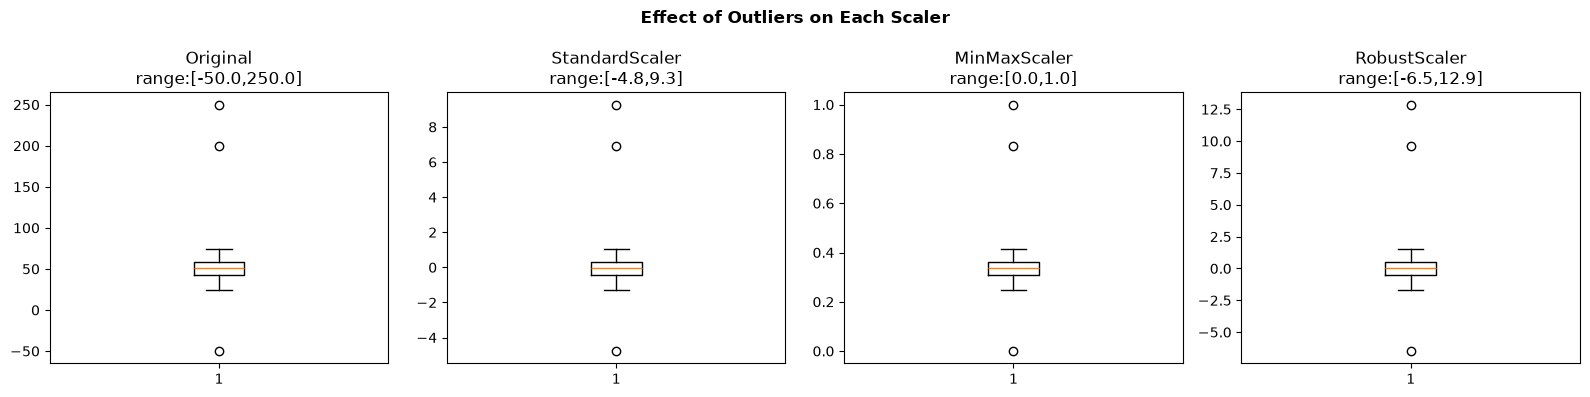

StandardScaler: mean=0, std=1. Outliers compress the rest.
MinMaxScaler:   0 to 1. Outliers shrink everything else to near-0.
RobustScaler:   uses median+IQR. ROBUST to outliers. Use when outliers present.


In [4]:
np.random.seed(0)
data = np.append(np.random.normal(50, 10, 200), [200, 250, -50])

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
scalers = {
    'Original'      : data,
    'StandardScaler': StandardScaler().fit_transform(data.reshape(-1,1)).ravel(),
    'MinMaxScaler'  : MinMaxScaler().fit_transform(data.reshape(-1,1)).ravel(),
    'RobustScaler'  : RobustScaler().fit_transform(data.reshape(-1,1)).ravel(),
}
for ax, (name, d) in zip(axes, scalers.items()):
    ax.boxplot(d)
    ax.set_title(f'{name}\nrange:[{d.min():.1f},{d.max():.1f}]')
plt.suptitle('Effect of Outliers on Each Scaler', fontweight='bold')
plt.tight_layout(); plt.savefig('/tmp/scaling.png', dpi=100); plt.show()
print('StandardScaler: mean=0, std=1. Outliers compress the rest.')
print('MinMaxScaler:   0 to 1. Outliers shrink everything else to near-0.')
print('RobustScaler:   uses median+IQR. ROBUST to outliers. Use when outliers present.')

## 3. Missing Data — MCAR / MAR / MNAR

| Type | Meaning | Strategy |
|---|---|---|
| **MCAR** — Missing Completely At Random | Random rows missing | Any imputation OK |
| **MAR** — Missing At Random | Missing depends on *other* observed columns | KNN or Iterative imputation |
| **MNAR** — Missing Not At Random | Missing depends on the *missing value itself* | Add missingness indicator column |

In [5]:
np.random.seed(42)
n = 300
df_m = pd.DataFrame({
    'Age'   : np.random.randint(20, 60, n).astype(float),
    'Income': np.random.normal(60000, 20000, n).clip(10000),
    'Score' : np.random.uniform(0, 100, n)
})

# MCAR: randomly missing
df_m.loc[np.random.choice(n, 30, replace=False), 'Score'] = np.nan

# MAR: Income missing more for young people
young = df_m[df_m['Age'] < 30].index
df_m.loc[np.random.choice(young, size=int(len(young)*0.5), replace=False), 'Income'] = np.nan

# MNAR: High income more likely missing
high  = df_m[df_m['Income'] > 80000].dropna().index
df_m.loc[np.random.choice(high, size=min(10,len(high)), replace=False), 'Income'] = np.nan

# Add missingness indicator for MNAR
df_m['Income_missing'] = df_m['Income'].isnull().astype(int)

print('Missing values:'); print(df_m.isnull().sum())
print()

# Compare imputation
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer

mean_imp = SimpleImputer(strategy='mean').fit_transform(df_m[['Income']])
knn_imp  = KNNImputer(n_neighbors=5).fit_transform(df_m[['Income','Age']])
iter_imp = IterativeImputer(max_iter=10, random_state=42).fit_transform(df_m[['Income','Age','Score']])

print(f'Mean imputed  Income mean: {np.nanmean(mean_imp):.0f}')
print(f'KNN  imputed  Income mean: {np.nanmean(knn_imp[:,0]):.0f}')
print(f'Iterative     Income mean: {np.nanmean(iter_imp[:,0]):.0f}')
print(f'True          Income mean: {df_m["Income"].dropna().mean():.0f}')

Missing values:
Age                0
Income            47
Score             30
Income_missing     0
dtype: int64

Mean imputed  Income mean: 58957
KNN  imputed  Income mean: 58897
Iterative     Income mean: 58957
True          Income mean: 58957


## 4. Cyclical Encoding for Date/Time

> **Classic interview question.** Hour 23 and hour 0 are 1 apart, not 23 apart. Raw numeric encoding gets this wrong.

**Fix:** encode as `sin(2*pi*val/period)` and `cos(2*pi*val/period)`

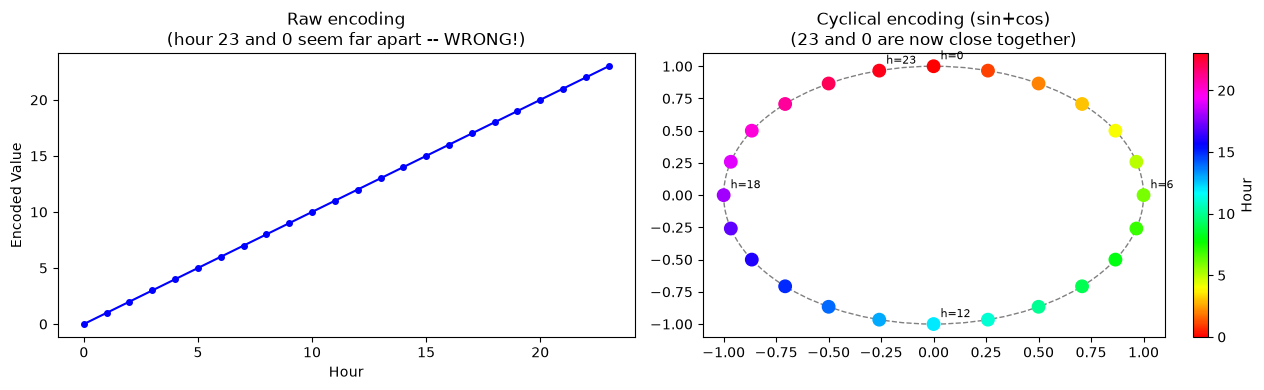

        date  day_of_week  month  is_weekend   day_sin   day_cos  month_sin  \
0 2024-01-01            0      1           0  0.000000  1.000000        0.5   
1 2024-01-02            1      1           0  0.781831  0.623490        0.5   
2 2024-01-03            2      1           0  0.974928 -0.222521        0.5   
3 2024-01-04            3      1           0  0.433884 -0.900969        0.5   
4 2024-01-05            4      1           0 -0.433884 -0.900969        0.5   

   month_cos  
0   0.866025  
1   0.866025  
2   0.866025  
3   0.866025  
4   0.866025  


In [6]:
hours = np.arange(24)
hour_sin = np.sin(2 * np.pi * hours / 24)
hour_cos = np.cos(2 * np.pi * hours / 24)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(hours, hours, 'b-o', ms=4)
axes[0].set_title('Raw encoding\n(hour 23 and 0 seem far apart -- WRONG!)')
axes[0].set_xlabel('Hour'); axes[0].set_ylabel('Encoded Value')

sc = axes[1].scatter(hour_sin, hour_cos, c=hours, cmap='hsv', s=80, zorder=5)
for h in [0, 6, 12, 18, 23]:
    axes[1].annotate(f'h={h}', (hour_sin[h], hour_cos[h]),
                     textcoords='offset points', xytext=(5,5), fontsize=8)
circle = plt.Circle((0,0), 1, fill=False, color='gray', linestyle='--')
axes[1].add_patch(circle)
axes[1].set_title('Cyclical encoding (sin+cos)\n(23 and 0 are now close together)')
plt.colorbar(sc, ax=axes[1], label='Hour')
plt.tight_layout(); plt.savefig('/tmp/cyclical.png', dpi=100); plt.show()

# Full datetime feature engineering example
dates = pd.date_range('2024-01-01', periods=365, freq='D')
df_dt = pd.DataFrame({'date': dates})
df_dt['day_of_week']  = df_dt['date'].dt.dayofweek
df_dt['month']        = df_dt['date'].dt.month
df_dt['is_weekend']   = df_dt['day_of_week'].isin([5,6]).astype(int)
df_dt['day_sin']      = np.sin(2*np.pi*df_dt['day_of_week']/7)
df_dt['day_cos']      = np.cos(2*np.pi*df_dt['day_of_week']/7)
df_dt['month_sin']    = np.sin(2*np.pi*df_dt['month']/12)
df_dt['month_cos']    = np.cos(2*np.pi*df_dt['month']/12)
print(df_dt.head())

## 5. Feature Importance — Why Four Methods Disagree

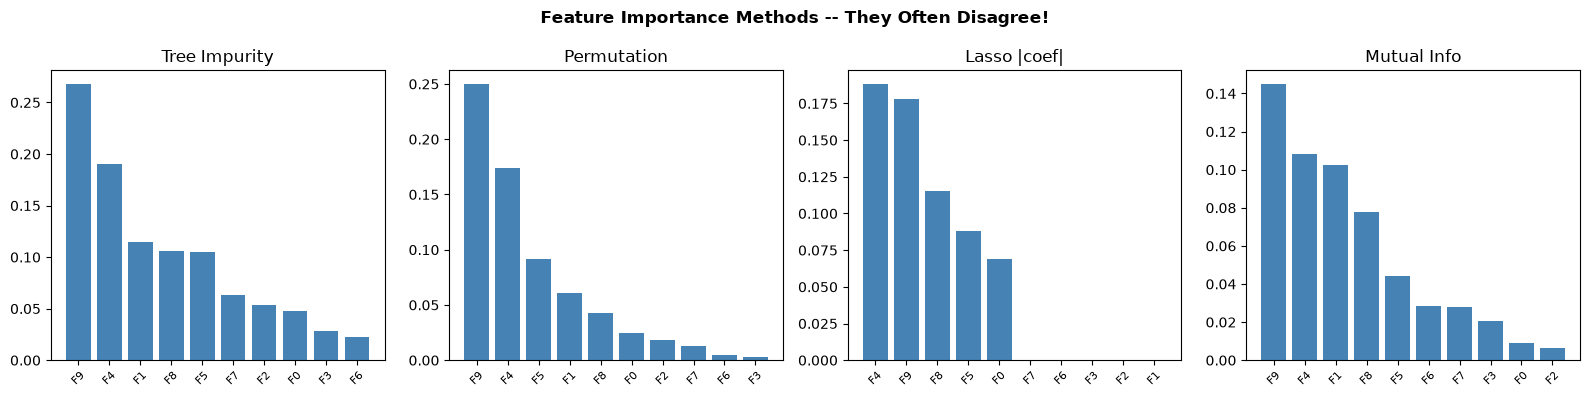

Tree impurity : biased toward high-cardinality features
Permutation   : model-agnostic, measures actual test impact (BEST)
Lasso coef    : only captures linear relationships
Mutual Info   : captures non-linear, but ignores redundancy


In [7]:
X_fi, y_fi = make_classification(n_samples=1000, n_features=10, n_informative=5,
                                   n_redundant=3, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X_fi, y_fi, test_size=0.3, random_state=42)
feat_names = [f'F{i}' for i in range(10)]

rf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_tr, y_tr)

tree_imp = rf.feature_importances_
perm_imp = permutation_importance(rf, X_te, y_te, n_repeats=20, random_state=42).importances_mean

sc = StandardScaler()
lasso = Lasso(alpha=0.01).fit(sc.fit_transform(X_tr), y_tr)
lasso_imp = np.abs(lasso.coef_)

mi_imp = mutual_info_classif(X_tr, y_tr, random_state=42)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, imp, title in zip(axes,
        [tree_imp, perm_imp, lasso_imp, mi_imp],
        ['Tree Impurity', 'Permutation', 'Lasso |coef|', 'Mutual Info']):
    order = np.argsort(imp)[::-1]
    ax.bar(range(10), imp[order], color='steelblue')
    ax.set_xticks(range(10))
    ax.set_xticklabels([feat_names[i] for i in order], rotation=45, fontsize=8)
    ax.set_title(title)
plt.suptitle('Feature Importance Methods -- They Often Disagree!', fontweight='bold')
plt.tight_layout(); plt.savefig('/tmp/feat_imp.png', dpi=100); plt.show()
print('Tree impurity : biased toward high-cardinality features')
print('Permutation   : model-agnostic, measures actual test impact (BEST)')
print('Lasso coef    : only captures linear relationships')
print('Mutual Info   : captures non-linear, but ignores redundancy')

## 6. Production Pipeline — Leakage-Free

In [8]:
np.random.seed(42)
n = 1000
raw = pd.DataFrame({
    'age'      : np.random.randint(20, 65, n).astype(float),
    'income'   : np.random.normal(60000, 20000, n).clip(10000),
    'city'     : np.random.choice(['Mumbai','Delhi','Bangalore','Chennai'], n),
    'education': np.random.choice(['HS','Bachelor','Master','PhD'], n),
    'target'   : np.random.choice([0,1], n, p=[0.7, 0.3])
})
raw.loc[np.random.choice(n, 50, replace=False), 'age']    = np.nan
raw.loc[np.random.choice(n, 40, replace=False), 'income'] = np.nan

X = raw.drop('target', axis=1)
y = raw['target']

# SPLIT FIRST -- always
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

num_pipe = Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())])
nom_pipe = Pipeline([('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
ord_pipe = Pipeline([('enc', OrdinalEncoder(categories=[['HS','Bachelor','Master','PhD']]))])

prep = ColumnTransformer([
    ('num', num_pipe, ['age','income']),
    ('nom', nom_pipe, ['city']),
    ('ord', ord_pipe, ['education']),
])

full_pipe = Pipeline([('prep', prep), ('clf', LogisticRegression(max_iter=500))])
full_pipe.fit(X_tr, y_tr)

from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_te, full_pipe.predict_proba(X_te)[:,1])
print(f'AUC-ROC: {auc:.4f}')
print()
print('Pipeline prevents leakage:')
print('  fit()       on train -> learns median/std/categories from train only')
print('  transform() on test  -> applies train statistics to test')
print('  predict()            -> one call handles full preprocessing + prediction')

AUC-ROC: 0.4406

Pipeline prevents leakage:
  fit()       on train -> learns median/std/categories from train only
  transform() on test  -> applies train statistics to test
  predict()            -> one call handles full preprocessing + prediction


## 7. VIF — Detecting Multicollinearity

In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

np.random.seed(42)
x1 = np.random.randn(200)
x2 = 0.95*x1 + np.random.randn(200)*0.1  # highly correlated
x3 = np.random.randn(200)                 # independent
x4 = x1 + x3                              # linear combination

X_vif = pd.DataFrame({'x1':x1,'x2':x2,'x3':x3,'x4':x4})
X_vif['const'] = 1

vif = pd.DataFrame({
    'feature': X_vif.columns[:-1],
    'VIF'    : [variance_inflation_factor(X_vif.values, i)
                for i in range(len(X_vif.columns)-1)]
}).sort_values('VIF', ascending=False)

print(vif.to_string(index=False))
print()
print('Rules: VIF=1 no corr | VIF 1-5 moderate | VIF>5 high | VIF>10 severe')
print()
print('INTERVIEW Q: Does multicollinearity affect all models equally?')
print('ANSWER: No. Linear/Logistic Regression coefficients become unstable.')
print('        Decision Trees and XGBoost are NOT affected.')
print('        Fix: remove one correlated feature, PCA, or use Ridge regression.')

feature      VIF
     x1      inf
     x3      inf
     x4      inf
     x2 83.79692

Rules: VIF=1 no corr | VIF 1-5 moderate | VIF>5 high | VIF>10 severe

INTERVIEW Q: Does multicollinearity affect all models equally?
ANSWER: No. Linear/Logistic Regression coefficients become unstable.
        Decision Trees and XGBoost are NOT affected.
        Fix: remove one correlated feature, PCA, or use Ridge regression.


## 8. Interview Traps — Never Get These Wrong

In [10]:
print('TRAP 1: Fitting scaler on full data before split')
print('  WRONG: scaler.fit_transform(X) then train_test_split')
print('  RIGHT: split first, then scaler.fit(X_train) only')
print()
print('TRAP 2: Target encoding on full dataset')
print('  WRONG: df["enc"] = df.groupby("city")["target"].transform("mean")')
print('  RIGHT: compute within each CV fold only')
print()
print('TRAP 3: OHE with unseen categories at test time')
print('  FIX  : OneHotEncoder(handle_unknown="ignore")')
print()
print('TRAP 4: Feature selection outside the pipeline')
print('  WRONG: select_features(X, y) then CV -> leaks test label signal')
print('  RIGHT: put SelectKBest or RFE inside the Pipeline')
print()
print('TRAP 5: Label encoding nominal features')
print('  WRONG: LabelEncoder on City -> Mumbai=0, Delhi=1, implies ordering')
print('  RIGHT: OneHotEncoder for unordered categories')
print()
print('TRAP 6: Applying different preprocessing to train vs test')
print('  FIX  : Use sklearn Pipeline -- one object, consistent transforms')

TRAP 1: Fitting scaler on full data before split
  WRONG: scaler.fit_transform(X) then train_test_split
  RIGHT: split first, then scaler.fit(X_train) only

TRAP 2: Target encoding on full dataset
  WRONG: df["enc"] = df.groupby("city")["target"].transform("mean")
  RIGHT: compute within each CV fold only

TRAP 3: OHE with unseen categories at test time
  FIX  : OneHotEncoder(handle_unknown="ignore")

TRAP 4: Feature selection outside the pipeline
  WRONG: select_features(X, y) then CV -> leaks test label signal
  RIGHT: put SelectKBest or RFE inside the Pipeline

TRAP 5: Label encoding nominal features
  WRONG: LabelEncoder on City -> Mumbai=0, Delhi=1, implies ordering
  RIGHT: OneHotEncoder for unordered categories

TRAP 6: Applying different preprocessing to train vs test
  FIX  : Use sklearn Pipeline -- one object, consistent transforms


In [11]:
print('FEATURE ENGINEERING - INTERVIEW CHEAT SHEET')
print('ENCODING')
print('  Ordinal ordered    -> OrdinalEncoder')
print('  Nominal low-card   -> OneHotEncoder drop=first')
print('  High-cardinality   -> TargetEncoder CV-safe or FrequencyEnc')
print('SCALING')
print('  No outliers        -> StandardScaler')
print('  Need 0-1 range     -> MinMaxScaler')
print('  Has outliers       -> RobustScaler')
print('  Tree models        -> No scaling needed')
print('MISSING DATA')
print('  MCAR -> Mean/Median imputation')
print('  MAR  -> KNN or Iterative imputation')
print('  MNAR -> Add missingness indicator column')
print('GOLDEN RULE')
print('  fit() on TRAIN only, transform() on both train and test')
print('  Use sklearn Pipeline to enforce this automatically')

FEATURE ENGINEERING - INTERVIEW CHEAT SHEET
ENCODING
  Ordinal ordered    -> OrdinalEncoder
  Nominal low-card   -> OneHotEncoder drop=first
  High-cardinality   -> TargetEncoder CV-safe or FrequencyEnc
SCALING
  No outliers        -> StandardScaler
  Need 0-1 range     -> MinMaxScaler
  Has outliers       -> RobustScaler
  Tree models        -> No scaling needed
MISSING DATA
  MCAR -> Mean/Median imputation
  MAR  -> KNN or Iterative imputation
  MNAR -> Add missingness indicator column
GOLDEN RULE
  fit() on TRAIN only, transform() on both train and test
  Use sklearn Pipeline to enforce this automatically
